---
title: "Chapter 10: Regression Metrics"
---

::: {.callout-lo}
By the end of this chapter, you will be able to:

- Choose preprocessing steps for a dataset with mixed feature types and missing values.
- Inspect transformed features and associate them with model coefficients.
- Fit and tune ridge regression, explaining how `alpha` affects model complexity and coefficient magnitudes.
- Interpret MSE, RMSE, $R^2$, and MAPE and choose a metric for a regression problem.
- Use regression metrics in cross-validation and hyperparameter search.
- Transform the target using `TransformedTargetRegressor` and return predictions to the original scale.
:::

In Chapter 9, we saw that the choice of evaluation metric depends on what kinds of mistakes matter. We now return to predicting a number: the sale price of a house. A prediction does not need to match the price exactly to be useful, so we need ways to describe how far our predictions are from the observed prices.

We will use the same housing dataset throughout the chapter: first preparing its features, then fitting and tuning ridge regression, comparing regression metrics, and finally transforming the target.

In [1]:
#| code-fold: true
#| code-summary: "Show imports and setup"

import os
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import (
    ColumnTransformer,
    TransformedTargetRegressor,
    make_column_transformer,
)
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.base import clone
from sklearn.linear_model import Ridge
from sklearn.metrics import make_scorer, mean_squared_error, r2_score
from sklearn.model_selection import (
    GridSearchCV,
    cross_val_score,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor

%matplotlib inline
DATA_DIR = Path("data")

# Ignore future deprecation warnings from sklearn (using `os` instead of `warnings` also works in subprocesses)
import os
os.environ['PYTHONWARNINGS']='ignore::FutureWarning'

## Preprocessing a realistic dataset

Earlier chapters introduced tools for scaling, imputation, and encoding. With a new dataset, the harder question is deciding which tools to use on which columns. We will work through those decisions using the [Kaggle House Prices dataset](https://www.kaggle.com/c/home-data-for-ml-course/), then use the resulting features throughout this chapter.

A useful approach is to ask five questions:

1. **What are we predicting, and what information will be available?** Define the target and the prediction setting before choosing features.
2. **What does each column mean?** Use the data description alongside summaries of the training data.
3. **What does a missing value mean?** An unknown measurement and an absent amenity need different treatment.
4. **How should the model represent each feature?** Choose an encoding based on meaning and the assumptions it introduces.
5. **Does the complete pipeline behave as intended?** Check feature coverage and transformed values, then evaluate the pipeline using cross-validation.

We will apply this approach to a few representative features before collecting the decisions into feature groups. You do not need to memorize the housing columns; focus on the questions behind the choices.

### Define the prediction setting and split the data

Our target is `SalePrice`, a continuous value in dollars, so this is a regression problem. For this exercise, we assume that the recorded property characteristics and sale circumstances are available when estimating the price, including the sale month and sale type. A tool used earlier, such as when a house is first listed, would need a fresh check of which inputs are available.

Kaggle provides separate training and test files. We use its labelled training file and make our own split, reserving 10% for final evaluation. A random split is our starting point for predicting other sales from a similar setting. Predicting future sales would instead call for a split that respects time.

Download the data into `data/housing-kaggle/` to run the examples. We explicitly treat `NA` and empty fields as missing but preserve the category `None`. In `MasVnrType`, which records the type of brick or stone exterior covering, `None` means the house has no such covering, not that the information is missing. We will use the data description to interpret the missing entries next.


In [2]:
df = pd.read_csv(
    DATA_DIR / "housing-kaggle/train.csv",
    keep_default_na=False,
    na_values=["", "NA"],
)
train_df, test_df = train_test_split(df, test_size=0.10, random_state=123)
train_df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
302,303,20,RL,118.0,13704,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2006,WD,Normal,205000
767,768,50,RL,75.0,12508,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,Shed,1300,7,2008,WD,Normal,160000
429,430,20,RL,130.0,11457,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,3,2009,WD,Normal,175000
1139,1140,30,RL,98.0,8731,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,144000
558,559,60,RL,57.0,21872,Pave,NaN,IR2,HLS,AllPub,...,0,NaN,NaN,NaN,0,8,2008,WD,Normal,175000


In [3]:
X_train = train_df.drop(columns=["SalePrice"])
y_train = train_df["SalePrice"]

X_test = test_df.drop(columns=["SalePrice"])
y_test = test_df["SalePrice"]

X_train.shape

(1314, 80)

### Inspect meanings as well as values

Explore the training data while leaving the test set aside. Start with a compact inventory: the stored data type, the proportion of missing entries, and the number of distinct observed values. These tell us where to investigate; they do not determine the preprocessing automatically.

In [4]:
feature_summary = pd.DataFrame({
    "dtype": X_train.dtypes.astype(str),
    "missing_fraction": X_train.isna().mean(),
    "distinct_values": X_train.nunique(),
})
feature_summary.sort_values("missing_fraction", ascending=False).head(15)

,dtype,missing_fraction,distinct_values
PoolQC,str,0.994673,3
MiscFeature,str,0.961948,4
Alley,str,0.938356,2
Fence,str,0.802892,4
FireplaceQu,str,0.477169,5
LotFrontage,float64,0.171233,104
GarageType,str,0.055556,6
GarageYrBlt,float64,0.055556,97
GarageQual,str,0.055556,5
GarageCond,str,0.055556,5


Read these summaries alongside the [data description](https://www.kaggle.com/c/home-data-for-ml-course/data?select=data_description.txt), also available in the downloaded `data_description.txt`. For example, a high missing proportion in `PoolQC` might look like poor data collection. The description tells us that `NA` means no pool. Dropping every column with many missing entries would overlook that distinction.

For numeric measurements, also inspect their ranges and typical values. Does a zero mean none, an unknown value, or a recording error? Is an unusually large value plausible?

In [5]:
X_train[["LotArea", "LotFrontage", "YearBuilt", "GarageYrBlt"]].describe()

,LotArea,LotFrontage,YearBuilt,GarageYrBlt
count,1314.000000,1089.000000,1314.000000,1241.000000
mean,10273.261035,69.641873,1970.995434,1978.209508
std,8997.895541,23.031794,30.198127,24.759774
min,1300.000000,21.000000,1872.000000,1900.000000
25%,7500.000000,59.000000,1953.000000,1961.000000
50%,9391.000000,69.000000,1972.000000,1979.000000
75%,11509.000000,80.000000,2000.000000,2002.000000
max,215245.000000,313.000000,2010.000000,2010.000000


For further exploration, try an automated data-profiling tool to generate a report summarizing the training data's distributions and missing values. Some tools to explore include: 


- [fg-data-profiling](https://github.com/data-centric-ai-community/fg-data-profiling)
- [skimpy](https://aeturrell.github.io/skimpy/)
- [Sweetviz](https://github.com/fbdesignpro/sweetviz)

These summaries can help you identify questions to investigate, but you still need to decide which patterns matter for the prediction problem and examine them further.

### Distinguish absence from unknown information

Consider two houses: one has no fireplace, and the other has a fireplace whose quality was not recorded. Replacing both missing quality values with the most common rating would erase a useful distinction and assign a rating to an amenity that does not exist.

For basement, fireplace, garage, and pool features, we can check a related area or count. When that value is zero, we replace missing descriptions with the explicit category `Absent`. If the amenity exists but its description is missing, we leave that entry missing for now. For `Alley`, `Fence`, and `MiscFeature`, we use the data dictionary's definition of `NA` as absence.

The function below applies those fixed rules to each row. It does not estimate anything from the dataset, so we can apply the same rules to both splits. In a deployed application, new inputs would need the same preparation. Medians, common categories, and scaling parameters will be learned separately inside the model pipeline.

In [6]:
def mark_absent_amenities(X):
    X = X.copy()
    amenity_columns = {
        "TotalBsmtSF": ["BsmtQual", "BsmtCond", "BsmtExposure",
                        "BsmtFinType1", "BsmtFinType2"],
        "Fireplaces": ["FireplaceQu"],
        "GarageArea": ["GarageType", "GarageFinish", "GarageQual", "GarageCond"],
        "PoolArea": ["PoolQC"],
    }
    for measurement, columns in amenity_columns.items():
        absent = X[measurement].eq(0)
        X.loc[absent, columns] = X.loc[absent, columns].fillna("Absent")

    for column in ["Alley", "Fence", "MiscFeature"]:
        X[column] = X[column].fillna("Absent")
    return X


X_train = mark_absent_amenities(X_train)
X_test = mark_absent_amenities(X_test)
X_train[["Fireplaces", "FireplaceQu", "GarageArea", "GarageQual"]].head(10)

,Fireplaces,FireplaceQu,GarageArea,GarageQual
302,1,TA,843,TA
767,0,Absent,423,TA
429,1,TA,576,TA
1139,1,Gd,495,TA
558,1,TA,406,TA
761,0,Absent,440,TA
1046,1,Gd,716,TA
1265,0,Absent,506,TA
1187,1,Fa,757,TA
783,1,TA,602,TA


These rules still depend on the reliability of the records. A missing basement rating in a house with positive basement area remains unknown, rather than being labelled `Absent`. Cross-checking related columns is useful whenever the meaning of missingness is ambiguous.

For unknown numeric measurements, we will use median imputation as a simple starting point. We will also add **missing-value indicators**: extra columns recording whether a value was missing before imputation. For example, filling `GarageYrBlt` with a median year does not claim that a house without a garage actually has one; the indicator and the `Absent` garage categories retain that information.

::: {.callout-reflection}
A house has `Fireplaces = 0` and a missing `FireplaceQu`. Another has `Fireplaces = 1` and a missing `FireplaceQu`. What should their prepared quality values be, and why would filling both with `TA` be misleading?
:::

### Choose representations from feature meanings

A column's Python data type is a clue, not a modelling decision. The following examples illustrate the choices we will make.

| Feature | Meaning | Starting representation | Reason or assumption |
|---|---|---|---|
| `Id` | Record identifier | Drop | It identifies a record rather than describing the property. |
| `LotArea` | Area in square feet | Numeric, imputed and scaled | Differences have quantitative meaning. |
| `MSSubClass` | Dwelling-type code | One-hot encoded | Code differences do not measure differences between houses. |
| `MoSold` | Month of sale | One-hot encoded | Allow seasonal effects without a constant price change per month. |
| `ExterQual` | Ordered exterior quality | Ordinal encoded and scaled | A compact representation that assumes equal steps between ratings for a linear model. |
| `FireplaceQu` | Fireplace quality, absence, or unknown quality | One-hot encoded | Give absence its own category without placing it on a quality scale. |

Let's examine the distinction between a numeric value and a category code.

In [7]:
numeric_looking_columns = X_train.select_dtypes(include=np.number).columns.tolist()
X_train[["MSSubClass", "MoSold"]].head()

,MSSubClass,MoSold
302,20,1
767,50,7
429,20,3
1139,30,5
558,60,8


The data description says that `MSSubClass = 20` represents a one-story dwelling built in 1946 or later, while `60` represents a two-story dwelling built in 1946 or later. A code of `60` does not mean three times as much dwelling as a code of `20`. We will treat these as categories.

`MoSold` is different: months have a sequence, but a numeric encoding in a linear model would impose the same predicted-price change from January to February as from November to December. One-hot encoding allows each month its own effect. It does not capture the closeness of December and January; that is a limitation of this simple choice.

#### Numeric features

We group measurements, counts, and years as numeric features. We also keep `OverallQual` and `OverallCond`, ratings from 1 to 10, as numeric scores. This is a modelling assumption: in a linear model, each additional rating point has the same contribution to predicted price. One-hot encoding those ratings would be an alternative to compare using cross-validation.

Raw years are another starting choice. Derived features such as age at sale might be useful, provided the required dates are available when predicting. We drop `Id` because we do not want to rely on the order in which records were assigned identifiers.

In [8]:
drop_features = ["Id"]
numeric_features = [
    "BedroomAbvGr",
    "KitchenAbvGr",
    "LotFrontage",
    "LotArea",
    "OverallQual",
    "OverallCond",
    "YearBuilt",
    "YearRemodAdd",
    "MasVnrArea",
    "BsmtFinSF1",
    "BsmtFinSF2",
    "BsmtUnfSF",
    "TotalBsmtSF",
    "1stFlrSF",
    "2ndFlrSF",
    "LowQualFinSF",
    "GrLivArea",
    "BsmtFullBath",
    "BsmtHalfBath",
    "FullBath",
    "HalfBath",
    "TotRmsAbvGrd",
    "Fireplaces",
    "GarageYrBlt",
    "GarageCars",
    "GarageArea",
    "WoodDeckSF",
    "OpenPorchSF",
    "EnclosedPorch",
    "3SsnPorch",
    "ScreenPorch",
    "PoolArea",
    "MiscVal",
    "YrSold",
]

In [9]:
# Numeric-looking columns that we will encode as categories.
[column for column in numeric_looking_columns
 if column not in numeric_features + drop_features]

['MSSubClass', 'MoSold']

#### Ordinal features

For four quality ratings, the data description gives the order Poor (`Po`), Fair (`Fa`), Typical (`TA`), Good (`Gd`), Excellent (`Ex`). We provide that order explicitly; alphabetical order would be incorrect. `Functional` has a separate scale, from salvage-only condition to typical functionality.

Ordinal encoding gives consecutive numbers to these categories. In ridge regression, this assumes equal changes in predicted price between adjacent levels, holding other inputs fixed. The ordering is supported by the description, but equal spacing is an approximation. We scale the encoded scores just as we scale numeric features. Scaling changes their units; it does not remove the equal-spacing assumption.

In [10]:
ordinal_features_reg = ["ExterQual", "ExterCond", "HeatingQC", "KitchenQual"]
ordering = ["Po", "Fa", "TA", "Gd", "Ex"]
ordering_ordinal_reg = [ordering] * len(ordinal_features_reg)

ordinal_features_oth = ["Functional"]
ordering_ordinal_oth = [
    ["Sal", "Sev", "Maj2", "Maj1", "Mod", "Min2", "Min1", "Typ"],
]

#### Remaining categorical features

We one-hot encode the remaining features, including the amenity descriptions with an `Absent` category. This uses more columns than ordinal encoding, but avoids imposing an ordering between absence and quality ratings. We also one-hot encode `Fence`: its labels mix privacy, material, and quality, so a single ranking would be difficult to justify.

The list below preserves the original column order. Inspect it against the data description: being left over does not, by itself, prove that a feature should be categorical.

In [11]:
assigned_features = (
    drop_features + numeric_features + ordinal_features_reg + ordinal_features_oth
)
categorical_features = [
    column for column in X_train.columns if column not in assigned_features
]
categorical_features

['MSSubClass',
 'MSZoning',
 'Street',
 'Alley',
 'LotShape',
 'LandContour',
 'Utilities',
 'LotConfig',
 'LandSlope',
 'Neighborhood',
 'Condition1',
 'Condition2',
 'BldgType',
 'HouseStyle',
 'RoofStyle',
 'RoofMatl',
 'Exterior1st',
 'Exterior2nd',
 'MasVnrType',
 'Foundation',
 'BsmtQual',
 'BsmtCond',
 'BsmtExposure',
 'BsmtFinType1',
 'BsmtFinType2',
 'Heating',
 'CentralAir',
 'Electrical',
 'FireplaceQu',
 'GarageType',
 'GarageFinish',
 'GarageQual',
 'GarageCond',
 'PavedDrive',
 'PoolQC',
 'Fence',
 'MiscFeature',
 'MoSold',
 'SaleType',
 'SaleCondition']

Before building the transformer, check that every input column is assigned exactly once. Otherwise, a column could be silently omitted or included through two different transformations.

In [12]:
all_features = assigned_features + categorical_features
assert len(all_features) == len(set(all_features)), "A feature appears in multiple groups."
assert set(all_features) == set(X_train.columns), "Check for missing or extra features."

::: {.callout-reflection}
Would `SalePrice / GrLivArea` (price per square foot) be a useful additional input when predicting `SalePrice` for a new house?

It uses the value we are trying to predict, so computing it from that house's sale price would leak the target. Feature engineering must use information available at prediction time. An area's historical prices might be usable, but they would need to come only from information available before the prediction.
:::

### Put the decisions into a pipeline

Now we can translate the choices into a `ColumnTransformer`. Each branch has a specific job:

| Feature group | Missing-value treatment | Transformation |
|---|---|---|
| Numeric | Training median, plus missing-value indicators | Standard scaling |
| Ordinal | Most frequent training category | Explicit ordinal encoding, then standard scaling |
| Categorical | A separate `Unknown` category for remaining missing entries | One-hot encoding |
| Identifier | Not applicable | Drop |

Most-frequent imputation for an unknown ordinal rating is a simple approximation, rather than evidence that the rating was typical. Crucially, these ordinal groups no longer contain the amenity columns where a missing rating can mean absence.

We scale numeric and ordinal inputs because ridge penalizes coefficient magnitudes, which depend on feature units. We leave one-hot indicators as 0/1, a common starting choice; that choice also affects how regularization treats those features. The numeric imputer adds indicators for columns with missing entries during fitting, and the scaler then scales both the filled measurements and their indicators.

For one-hot encoding, `handle_unknown="ignore"` lets us transform a category not seen during fitting: its feature's indicator columns are all zero. That is distinct from the explicit `Unknown` label used for missing entries. We request dense output to make the transformed table easy to inspect; for much larger datasets, a sparse representation may be more practical.

In [13]:
numeric_transformer = make_pipeline(
    SimpleImputer(strategy="median", add_indicator=True),
    StandardScaler(),
)
ordinal_transformer_reg = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OrdinalEncoder(categories=ordering_ordinal_reg),
    StandardScaler(),
)
ordinal_transformer_oth = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OrdinalEncoder(categories=ordering_ordinal_oth),
    StandardScaler(),
)
categorical_transformer = make_pipeline(
    SimpleImputer(strategy="constant", fill_value="Unknown"),
    OneHotEncoder(handle_unknown="ignore", sparse_output=False),
)

preprocessor = make_column_transformer(
    ("drop", drop_features),
    (numeric_transformer, numeric_features),
    (ordinal_transformer_reg, ordinal_features_reg),
    (ordinal_transformer_oth, ordinal_features_oth),
    (categorical_transformer, categorical_features),
    verbose_feature_names_out=False,
)

### Inspect the result and evaluate the complete workflow

Fit the preprocessor on the training inputs to inspect what it produces. Recovering feature names helps us check the encodings now and match features to model coefficients later.

In [14]:
preprocessor.fit(X_train)
new_columns = preprocessor.get_feature_names_out()
X_train_enc = pd.DataFrame(
    preprocessor.transform(X_train), index=X_train.index, columns=new_columns
)
X_train_enc.head()

,BedroomAbvGr,KitchenAbvGr,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
302,0.154795,-0.222647,2.312501,0.381428,0.663680,-0.512408,0.993969,0.840492,0.269972,-0.961498,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
767,1.372763,-0.222647,0.260890,0.248457,-0.054669,1.285467,-1.026793,0.016525,-0.573129,0.476092,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
429,0.154795,-0.222647,2.885044,0.131607,-0.054669,-0.512408,0.563314,0.161931,-0.573129,1.227559,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1139,0.154795,-0.222647,1.358264,-0.171468,-0.773017,-0.512408,-1.689338,-1.679877,-0.573129,0.443419,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
558,0.154795,-0.222647,-0.597924,1.289541,0.663680,-0.512408,0.828332,0.598149,-0.573129,0.354114,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [15]:
print(f"Original features: {X_train.shape[1]}")
print(f"Transformed features: {X_train_enc.shape[1]}")
assert X_train_enc.columns.is_unique
assert np.isfinite(X_train_enc.to_numpy()).all()

# Check that houses without fireplaces retain that information.
X_train_enc.loc[
    X_train["Fireplaces"].eq(0),
    X_train_enc.columns.str.startswith("FireplaceQu_"),
].head()

Original features: 80
Transformed features: 313


,FireplaceQu_Absent,FireplaceQu_Ex,FireplaceQu_Fa,FireplaceQu_Gd,FireplaceQu_Po,FireplaceQu_TA
767,1.0,0.0,0.0,0.0,0.0,0.0
761,1.0,0.0,0.0,0.0,0.0,0.0
1265,1.0,0.0,0.0,0.0,0.0,0.0
679,1.0,0.0,0.0,0.0,0.0,0.0
1269,1.0,0.0,0.0,0.0,0.0,0.0


One-hot encoding expands individual categorical features into several columns, and missing-value indicators add further columns. The checks above confirm that names are unique and the transformed training values contain no missing or infinite entries. They do not establish that our choices predict well; that requires evaluation.

The fit above is for inspection. When we use cross-validation, we will pass the **raw, prepared feature table and a pipeline containing both the preprocessor and the model**. Each fold must learn its medians, common categories, scaling parameters, and one-hot categories from that fold's training portion. Cross-validating a model on `X_train_enc` would instead reuse preprocessing learned from all the training rows, including the validation folds.

Our choices are a starting point to evaluate, with assumptions we can revisit. Median imputation may hide relationships between measurements; ordinal encoding assumes equal steps; and numeric years impose a simple time trend. Compare alternatives using training-set cross-validation, keeping the test set for final evaluation. Investigate unusual records before deciding whether they are errors: an unusual house is not automatically invalid.

For a new dataset, keep a small decision table like the one above: **feature meaning, availability at prediction time, meaning of missing values, chosen transformation, and its assumptions**. This makes the preprocessing explainable and gives you specific choices to revisit when evaluating the model.

## Building and tuning a regression model

With preprocessing in place, we can follow a familiar workflow: compare a model with a simple baseline, tune its hyperparameter using cross-validation, and inspect the selected model. We will keep the test set aside during these decisions.

### Compare ridge regression with a baseline

`DummyRegressor` predicts the mean training price for every house by default. Ridge regression uses the property features to make different predictions for different houses. Does that extra information improve predictions on held-out examples?

For now, we compare models using **$R^2$**, the default score for ridge regression. Higher is better: 1 means perfect predictions, 0 matches predicting the evaluation set's mean price, and negative values are worse than that reference. A dummy model can score slightly below zero because it predicts the *training* mean, which need not equal the validation mean. We will examine the formula and its limitations in the next section.

We use the same ten folds for both models. The ridge pipeline fits its preprocessing separately within each fold.

In [16]:
pipe_ridge = make_pipeline(preprocessor, Ridge())
cv_results = {}
for name, model in {"Dummy": DummyRegressor(), "Ridge": pipe_ridge}.items():
    cv_results[name] = cross_validate(
        model, X_train, y_train, cv=10, scoring="r2", return_train_score=True
    )

pd.DataFrame({
    name: {
        "mean training R2": result["train_score"].mean(),
        "mean validation R2": result["test_score"].mean(),
        "validation R2 std": result["test_score"].std(),
    }
    for name, result in cv_results.items()
}).T

,mean training R2,mean validation R2,validation R2 std
Dummy,0.000000,-0.010903,0.022123
Ridge,0.921452,0.790942,0.175883


Ridge improves substantially on the baseline, but its validation scores vary across folds. In the lowest-scoring fold, one house accounts for about 80% of the squared error: the model predicts approximately \$827,000 for a house that sold for \$160,000. The house is unusually large and has a high quality rating, but a comparatively low sale price. A few large errors can strongly affect $R^2$; inspect such records before deciding whether they are errors or difficult but valid examples.

### Tune the regularization strength

Ridge is a linear model whose `alpha` parameter controls regularization. Larger `alpha` penalizes large coefficients more strongly, restricting how closely the model can fit the training data. Too little regularization can allow overfitting; too much can cause underfitting. This direction is opposite to `C` in logistic regression, where larger `C` means weaker regularization.

We use `GridSearchCV` around the complete pipeline so that preprocessing is refitted within each training fold. The name `ridge__alpha` tells the search to change `alpha` in the pipeline's ridge step.

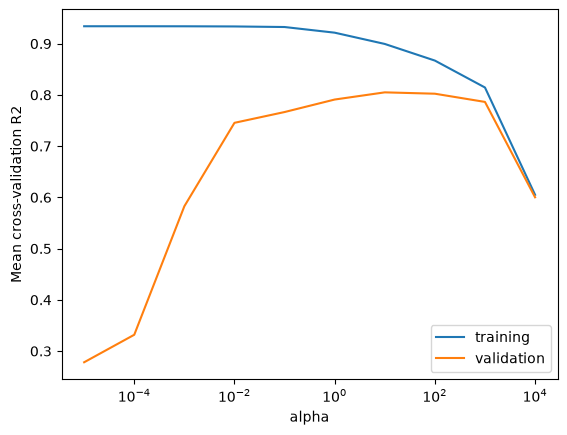

In [17]:
param_grid = {"ridge__alpha": 10.0 ** np.arange(-5, 5)}
search = GridSearchCV(
    pipe_ridge, param_grid, cv=10, scoring="r2",
    return_train_score=True, n_jobs=-1,
)
search.fit(X_train, y_train)

plt.semilogx(
    param_grid["ridge__alpha"], search.cv_results_["mean_train_score"], label="training"
)
plt.semilogx(
    param_grid["ridge__alpha"], search.cv_results_["mean_test_score"], label="validation"
)
plt.xlabel("alpha")
plt.ylabel("Mean cross-validation R2")
plt.legend();

::: {.callout-reflection}
Before checking the selected value, identify the region of the curve you would choose. Why would selecting the highest training score be a poor rule? What happens to both scores when regularization becomes too strong?
:::

The search selects the candidate with the highest mean validation score and, by default, refits that pipeline on all the training data. We can reuse `best_estimator_` without fitting another model.

In [18]:
best_alpha = search.best_params_["ridge__alpha"]
ridge_tuned = search.best_estimator_
print(f"Selected alpha: {best_alpha:g}")
print(f"Best mean validation R2: {search.best_score_:.3f}")

Selected alpha: 10
Best mean validation R2: 0.805


This is the best value among the candidates for these folds and preprocessing choices, not a universally best `alpha`. The score was used to select the model; it is not a final test-set estimate.

### Inspect what regularization changes

To make the effect concrete, compare a few coefficients under weak, selected, and strong regularization. We keep the features and training data fixed. `clone` creates an independent copy of the pipeline for each comparison, leaving the selected model unchanged.

In [19]:
features_to_compare = [
    "OverallQual", "GrLivArea", "KitchenQual", "Neighborhood_Edwards"
]
selected_preprocessor = ridge_tuned.named_steps["columntransformer"]
selected_coefficients = pd.Series(
    ridge_tuned.named_steps["ridge"].coef_,
    index=selected_preprocessor.get_feature_names_out(),
)
coefficient_comparison = {}
for label, alpha in [("Weak (0.01)", 0.01), ("Strong (1000)", 1000)]:
    model = clone(pipe_ridge).set_params(ridge__alpha=alpha)
    model.fit(X_train, y_train)
    coefficient_comparison[label] = pd.Series(
        model.named_steps["ridge"].coef_,
        index=model.named_steps["columntransformer"].get_feature_names_out(),
    )

selected_label = f"Selected ({best_alpha:g})"
coefficient_comparison[selected_label] = selected_coefficients
pd.DataFrame(coefficient_comparison).loc[
    features_to_compare, ["Weak (0.01)", selected_label, "Strong (1000)"]
].round(0)

,Weak (0.01),Selected (10),Strong (1000)
OverallQual,10291.0,13450.0,9137.0
GrLivArea,15589.0,14462.0,7549.0
KitchenQual,3744.0,4167.0,5567.0
Neighborhood_Edwards,-16983.0,-15072.0,-1118.0


Stronger regularization shrinks the coefficient vector overall, although an individual coefficient need not decrease in magnitude at every step, especially when features are correlated. Smaller coefficients alone do not establish a better model; validation performance guides the choice.

In the selected model, the positive `OverallQual` coefficient associates higher quality with higher predicted price, holding other encoded inputs fixed. Since this feature was standardized, its coefficient describes a one-standard-deviation increase, not a one-point increase in the original rating. `Neighborhood_Edwards` is a 0/1 indicator with a negative coefficient. Comparing two neighbourhoods requires comparing their coefficients; this coefficient alone is not an absolute neighbourhood price discount. These are model associations, not causal effects.

### Exercise 10.1: Choosing a model

A smaller `alpha` improves the training score but lowers the mean validation score. A classmate recommends it because it fits the observed house prices more closely. Explain why you might prefer the larger `alpha`, and why checking several alternatives on the test set would not be a good way to settle the disagreement.

::: {.callout-tip collapse="true" title="Solution"}
We care about predictions for new houses, so a better fit to the training data is not enough. The smaller `alpha` allows a more flexible fit, but its lower mean validation score suggests that this flexibility is hurting generalization. We would prefer the larger `alpha` based on its better validation performance, while also considering how much the scores vary across folds.

Comparing alternatives on the test set would use that set to select the model. Its score would then no longer provide an independent final evaluation and could be overly optimistic. Use cross-validation on the training data to choose `alpha`, then evaluate the selected model on the test set.
:::


We now have a selected model, but $R^2$ does not tell us how many dollars its predictions are typically off by. Next, we will examine regression metrics that answer different questions about prediction errors.

## Evaluating regression predictions

For classification, we could ask whether a predicted label matched the observed label. For house prices, exact equality is too strict: predicting \$301,000 for a house that sells for \$300,000 is a small error. We need metrics that account for the size of the errors.

Which metric should we use? Start with the question the predictions need to answer:

- **How large are the errors in dollars?** MAE and RMSE express error in the target's units, but give different emphasis to large mistakes.
- **How well do predictions compare with a simple reference?** $R^2$ compares squared error with predicting the evaluation set's mean.
- **How large are errors relative to each house's price?** MAPE measures proportional error, with limitations near zero.

We will calculate these metrics on the selected model's training predictions to understand their meanings. These training scores do not estimate performance on new houses. We will then use the metrics in cross-validation and model selection.

### Mean absolute error (MAE): average error in dollars

A simple way to measure error is to take the absolute difference between each prediction and its observed price, then average those differences. Taking absolute values prevents overpredictions and underpredictions from cancelling out.

Writing the observed prices as $y_i$ and the predictions as $\hat{y}_i$, the **mean absolute error** is

$$\operatorname{MAE} = \frac{1}{n}\sum_{i=1}^{n}|y_i - \hat{y}_i|.$$

MAE is in dollars for this problem. It is useful when each additional dollar of absolute error should contribute equally to the evaluation.

In [20]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

preds = ridge_tuned.predict(X_train)
mae = mean_absolute_error(y_train, preds)
print(f"Training MAE: ${mae:,.0f}")

# The same calculation using NumPy.
np.mean(np.abs(y_train - preds))

Training MAE: $15,592


np.float64(15592.325430847972)

An MAE of \$20,000 would mean an average absolute error of \$20,000 on the evaluated houses. It would not mean that every prediction, or even most predictions, falls within \$20,000 of the actual price. Inspect the distribution of errors as well as their average.

### Mean squared error (MSE): emphasize large mistakes

What if a few very large mistakes are especially concerning? Squaring errors gives them greater influence: an error of \$20,000 contributes four times as much as an error of \$10,000. Under MAE it contributes only twice as much.

The **mean squared error** is

$$\operatorname{MSE} = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2.$$

As with MAE, smaller is better, and perfect predictions have an error of zero.

In [21]:
mse = mean_squared_error(y_train, preds)
pd.Series({
    "MSE (NumPy)": np.mean((y_train - preds) ** 2),
    "MSE (scikit-learn)": mse,
})

MSE (NumPy)           6.447903e+08
MSE (scikit-learn)    6.447903e+08
dtype: float64

The MSE is about 645 million, but this is not an error of 645 million dollars. Squaring a difference measured in dollars gives **squared dollars**. MSE is useful for expressing a squared-error criterion, including the error term in ridge's fitting objective, but its units make it awkward to communicate.

Changing units also changes its value. Expressing prices in cents multiplies each error by 100 and MSE by $100^2 = 10{,}000$.

### Root mean squared error (RMSE): squared-error emphasis in familiar units

Taking the square root of MSE gives **RMSE**, which is in the same units as the target:

$$\operatorname{RMSE} = \sqrt{\operatorname{MSE}}.$$

Use RMSE when you want an error measure in dollars that gives large mistakes more influence than MAE does.

In [22]:
rmse = np.sqrt(mse)
print(f"Training MAE:  ${mae:,.0f}")
print(f"Training RMSE: ${rmse:,.0f}")

Training MAE:  $15,592
Training RMSE: $25,393


The training RMSE is about \$25,400. RMSE is at least as large as MAE on the same predictions, and a substantial gap can indicate that a few large errors deserve closer inspection. Neither metric gives a bound on individual errors.

To see their different emphasis, consider errors on three houses. Model A is exactly right twice but misses by \$30,000 once. Model B misses by \$10,000 on every house. Before running the code, predict which metric will distinguish them.

In [23]:
example_errors = pd.DataFrame({
    "Model A": [0, 0, 30_000],
    "Model B": [10_000, 10_000, 10_000],
})
pd.DataFrame({
    "MAE ($)": example_errors.abs().mean(),
    "RMSE ($)": np.sqrt((example_errors ** 2).mean()),
}).round(0)

,MAE ($),RMSE ($)
Model A,10000.0,17321.0
Model B,10000.0,10000.0


MAE treats these models equally because their total absolute errors are equal. RMSE prefers Model B because its errors are spread evenly rather than concentrated in one large mistake. Which judgment is useful depends on the consequences of those errors. Neither metric automatically represents an application's costs.

MSE and RMSE rank models identically on a **single fixed evaluation set**: taking a square root does not change which value is smaller. They are two scales for the same squared-error criterion, rather than two independent pieces of evidence.

::: {.callout-note collapse="true" title="A cross-validation subtlety"}
The mean of the fold RMSEs is not generally the square root of the mean fold MSE. Taking a square root before averaging can change the ranking of candidates. If selecting models by mean cross-validation RMSE, use the RMSE scorer directly and report how the scores were averaged.
:::

### Inspect errors as well as summarizing them

MAE and RMSE discard the direction of errors. A plot of observed and predicted prices helps us see patterns that a single score can hide.

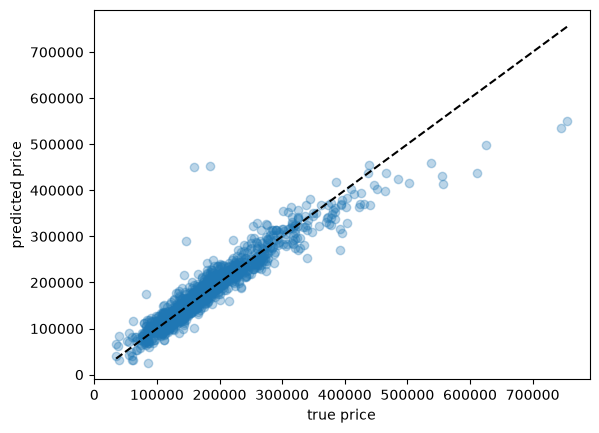

In [24]:
plt.scatter(y_train, preds, alpha=0.3)
grid = np.linspace(y_train.min(), y_train.max(), 1000)
plt.plot(grid, grid, "--k")
plt.xlabel("true price")
plt.ylabel("predicted price");

Each point compares a house’s observed price with its predicted price. Points above the dashed line represent overpredictions; points below it represent underpredictions. Because many points overlap, this plot alone does not clearly show whether overprediction or underprediction is more common. We can count each directly:


In [25]:
# Positive errors indicate overprediction; negative errors indicate underprediction.
errors = preds - y_train
print(f"Overpredictions: {(errors > 0).mean():.1%}")
print(f"Underpredictions: {(errors < 0).mean():.1%}")
print(f"Exact matches: {(errors == 0).mean():.1%}")

Overpredictions: 50.5%
Underpredictions: 49.5%
Exact matches: 0.0%


These percentages describe how often the model predicts too high or too low on the training set, not how large those errors are. Even similar percentages can hide a few very large errors in one direction. RMSE summarizes error magnitude but does not tell us the direction of the errors.

### Coefficient of determination ($R^2$): compare with a reference

For the regressors used here, `.score()` returns $R^2$ by default. This metric compares squared prediction errors with the squared deviations of the observed targets from their mean:

$$R^2(y, \hat{y}) = 1 - \frac{\sum_{i=1}^n (y_i - \hat{y}_i)^2}{\sum_{i=1}^n (y_i - \bar{y})^2}.$$

The numerator measures the model's squared error. The denominator measures the squared error of predicting the mean of the **evaluation targets** for every example. A perfect prediction has $R^2=1$; a value of 0 matches that reference; and a negative value is worse. This reference is not necessarily the same as a `DummyRegressor` fitted on a separate training set.

In [26]:
r2_score(y_train, preds)

0.8967140073405423

For example, $R^2=0.8$ means the model's squared error is 20% of the reference's squared error on that evaluation set. It does not mean that 80% of predictions are correct.

Use $R^2$ to give context to squared error, and pair it with MAE or RMSE when readers need to understand errors in dollars. On a fixed evaluation set with varying targets, maximizing $R^2$ gives the same model ranking as minimizing MSE. Across different datasets, however, $R^2$ depends on how much the targets vary, so it is not a universal measure of prediction difficulty. The formula is undefined when all evaluation targets are identical; scikit-learn uses special handling for that case.

Keep the argument order `r2_score(y_true, y_pred)`: reversing it changes which values define the reference mean.

### Mean absolute percentage error (MAPE): compare proportional errors

An error of \$30,000 on a \$600,000 house is 5% of its price; the same error on a \$60,000 house is 50%. Both contribute equally to MAE and MSE. If proportional errors matter, we need a different measure.

**MAPE** averages the absolute error divided by the absolute true value:

$$\operatorname{MAPE} = \frac{1}{n}\sum_{i=1}^{n}\frac{|y_i - \hat{y}_i|}{|y_i|}.$$

Here we express MAPE as a proportion, matching scikit-learn. Multiply by 100 to report a percentage.

In [27]:
mape = mean_absolute_percentage_error(y_train, preds)
print(f"Training MAPE: {mape:.1%}")

Training MAPE: 9.3%


The training MAPE is about 9.3%: the average absolute error relative to each house's own price. Use MAPE when relative size is meaningful and the targets are safely above zero. It gives the same dollar error more weight for a cheaper house.

MAPE is undefined at a true value of zero and can be dominated by values close to zero. Scikit-learn avoids division by zero using a small positive denominator, but the resulting error can still be enormous. For demand data containing zero sales, MAE or RMSE is usually a more interpretable starting point. Percentage errors also need a meaningful zero: they are not sensible for temperatures measured in degrees Celsius.

### Choose a metric from the prediction's purpose

Start with what happens when a prediction is wrong. For a housing report that needs an average dollar discrepancy, MAE is a useful starting point. If large dollar errors deserve extra emphasis, report RMSE. If the goal is comparable proportional accuracy across inexpensive and expensive houses, consider MAPE and check its assumptions.

| Evaluation question | Useful metric | What to keep in mind |
|---|---|---|
| How large is the average absolute error in the target's units? | MAE | Each additional unit of absolute error contributes equally; inspect large errors separately. |
| How large are errors when large mistakes receive extra emphasis? | RMSE | Large errors can dominate; investigate whether unusual records are valid. |
| What is the average squared error? | MSE | Useful for squared-error comparisons, but its squared units are harder to communicate. |
| How does squared error compare with predicting the evaluation mean? | $R^2$ | Gives context, not an error in dollars; depends on target variation. |
| How large are errors relative to the true values? | MAPE | Requires meaningful ratios and targets away from zero; emphasizes errors on smaller targets. |

All these measures treat overprediction and underprediction equally for a fixed target and error magnitude. If underestimating is more costly than overestimating, none directly captures that asymmetry. Inspect signed errors and consider an evaluation criterion based on the actual costs.

Choose a primary metric before comparing models, then use a small number of additional metrics and plots to understand its limitations. Do not pick whichever metric makes a preferred model look best. See the [scikit-learn regression metrics guide](https://scikit-learn.org/stable/modules/model_evaluation.html#regression-metrics) for further details.

### Use the chosen metric in cross-validation

Metric functions such as `mean_absolute_error` return nonnegative errors, where smaller is better. Scikit-learn's *scorers* follow a higher-is-better convention, so error scorers negate the error. For example, an MAE of 20,000 becomes a score of −20,000, which is better than −30,000.

Here we evaluate the default ridge pipeline using several metrics on the same folds. We convert the negative error scores back to positive errors for reporting.

In [28]:
scoring = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2",
    "MAPE": "neg_mean_absolute_percentage_error",
}
metric_cv = cross_validate(pipe_ridge, X_train, y_train, cv=10, scoring=scoring)
fold_metrics = pd.DataFrame({
    name: metric_cv[f"test_{name}"] * (1 if name == "R2" else -1)
    for name in scoring
})
fold_metrics.agg(["mean", "std"])

,MAE,RMSE,R2,MAPE
mean,19550.116619,33938.348614,0.790942,0.118115
std,1916.136459,12064.060261,0.185397,0.011533


MAE and RMSE are in dollars; MAPE is a proportion; $R^2$ is unitless. These values describe different properties, so comparing their numerical sizes with one another is not meaningful. The standard deviations show variation across folds, not confidence intervals.

For a metric without a built-in scorer, `make_scorer` adapts a function taking observed values and predictions. The short MAPE implementation below illustrates the mechanism; it assumes nonzero targets. For ordinary use, prefer the built-in MAPE scorer.

In [29]:
def my_mape(true, pred):
    # For this example, all sale prices are positive.
    return np.mean(np.abs((true - pred) / true))

mape_scorer = make_scorer(my_mape, greater_is_better=False)
# This callable can be passed as scoring=mape_scorer.
mape_scorer(ridge_tuned, X_train, y_train)

np.float64(-0.09299437196491137)

`greater_is_better=False` tells the scorer to negate the returned error. It does not change the predictions or how the model was fitted.

### Select a model using the metric that matters

Suppose our goal is proportional accuracy across house prices. We can search over `alpha` using MAPE to select the model while recording the other metrics. `refit="MAPE"` chooses the candidate with the best MAPE score and refits its complete pipeline on all the training data.

Changing the evaluation metric does **not** change ridge's fitting objective. Each candidate still fits using squared error plus a regularization penalty. MAPE determines which fitted candidate we select. The same distinction applies if we select using MAE.

In [30]:
# Reuse the candidates and folds from the earlier R2 search.
search_multi = GridSearchCV(
    pipe_ridge, param_grid, cv=10, scoring=scoring,
    refit="MAPE", n_jobs=-1,
)
search_multi.fit(X_train, y_train)

print(f"Alpha selected by R2: {best_alpha:g}")
print(f"Alpha selected by MAPE: {search_multi.best_params_['ridge__alpha']:g}")
print(f"Best mean validation MAPE: {-search_multi.best_score_:.1%}")

search_results = pd.DataFrame({
    "alpha": search_multi.cv_results_["param_ridge__alpha"],
    "validation MAE ($)": -search_multi.cv_results_["mean_test_MAE"],
    "validation RMSE ($)": -search_multi.cv_results_["mean_test_RMSE"],
    "validation R2": search_multi.cv_results_["mean_test_R2"],
    "validation MAPE": -search_multi.cv_results_["mean_test_MAPE"],
})
search_results.sort_values("validation MAPE")

Alpha selected by R2: 10
Alpha selected by MAPE: 100
Best mean validation MAPE: 10.7%


,alpha,validation MAE ($),validation RMSE ($),validation R2,validation MAPE
7,100.00000,18309.849244,33096.990754,0.802324,0.107254
6,10.00000,18660.027872,32858.436410,0.804964,0.112304
8,1000.00000,20054.592512,35454.194161,0.786296,0.113340
5,1.00000,19550.116619,33938.348614,0.790942,0.118115
4,0.10000,19758.718047,35417.546965,0.766540,0.120150
3,0.01000,20219.600634,36983.649670,0.745495,0.123110
2,0.00100,21322.325266,44915.018561,0.582688,0.129091
1,0.00010,22211.253737,51925.732689,0.331826,0.133989
0,0.00001,22362.654749,53130.382687,0.278169,0.134832
9,10000.00000,31988.279251,49668.619333,0.600139,0.192341


Different metrics may select different values of `alpha`; agreement is also possible. What matters is choosing the criterion for the application's purpose. The search scores helped select a model, so we reserve the test set for evaluating the resulting choice.

In [31]:
mape_selected = search_multi.best_estimator_
test_predictions = mape_selected.predict(X_test)
print(f"Test MAPE: {mean_absolute_percentage_error(y_test, test_predictions):.1%}")
print(f"Test MAE: ${mean_absolute_error(y_test, test_predictions):,.0f}")

Test MAPE: 9.3%
Test MAE: $16,994


### Exercise 10.2: Choose a metric for the decision

For each situation, choose a primary metric and explain one limitation you would check.

1. A housing valuation team wants each additional dollar of absolute error to count equally, regardless of the house's price. A colleague suggests MAPE because it is unitless. Do you agree?
2. A delivery service predicts travel time in minutes. It wants large timing errors to receive disproportionately more emphasis than small ones. Would you use MAE or RMSE? If late arrivals are more costly than equally early arrivals, does your choice fully capture that concern?

::: {.callout-tip collapse="true" title="Solution"}
**1. Use MAE.** It weights each dollar of absolute error equally and reports the result in dollars. MAPE would give the same dollar error more influence for a cheaper house, which conflicts with the stated goal. MAE can hide a small number of large mistakes, so also inspect the error distribution.

**2. Use RMSE.** Squaring the errors gives large mistakes greater influence, and taking the square root returns the result to minutes. Investigate whether extreme errors reflect valid difficult trips or data problems. RMSE treats equally large early and late errors alike, so it does not capture the service's asymmetric costs; those need a separate analysis or cost-based criterion.
:::

The metric should express what matters about prediction errors. Next, we will change the scale on which the model fits the target and examine how that differs from changing the evaluation metric.

## Transforming the target

So far, preprocessing has changed the input features while leaving sale prices in dollars. We can also transform the target before fitting a model, then undo that transformation when making predictions. House prices provide a useful example because their range is wide and their distribution is skewed.

### Examining the target distribution

Let’s inspect the distribution of sale prices in the training set.

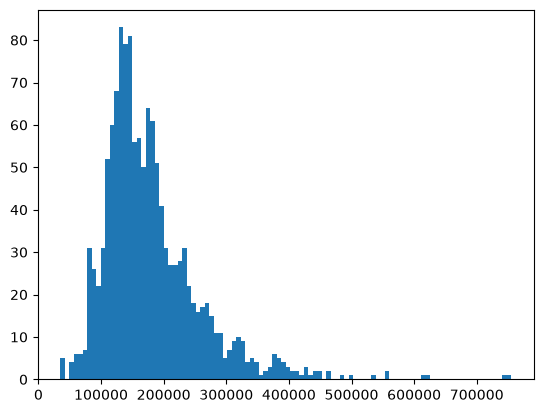

In [32]:
plt.hist(y_train, bins=100);

A log transformation compresses large values more than small ones. This can be useful when relative differences matter. A less skewed target distribution alone does not guarantee a better model; we still need to evaluate the resulting predictions.

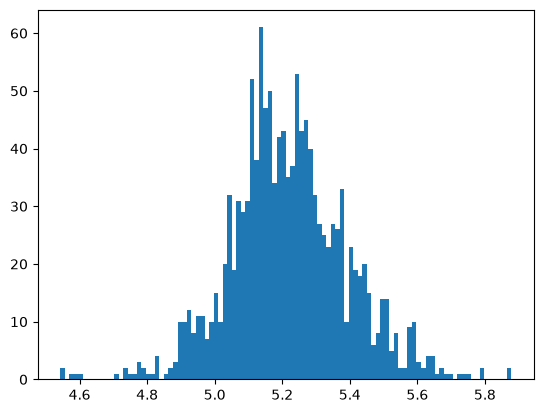

In [33]:
plt.hist(np.log10(y_train), bins=100);

### Fitting with `TransformedTargetRegressor`

`TransformedTargetRegressor` applies a transformation to the training targets and the inverse transformation to predictions. Our model below uses `log1p` and its inverse, `expm1`.

In [34]:
from sklearn.compose import TransformedTargetRegressor

In [35]:
ttr = TransformedTargetRegressor(
    Ridge(alpha=best_alpha), func=np.log1p, inverse_func=np.expm1
) # transformer for log transforming the target
ttr_pipe = make_pipeline(preprocessor, ttr)

In [36]:
ttr_pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('columntransformer', ...), ('transformedtargetregressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('drop', ...), ('pipeline-1', ...), ...]"
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and `

Why can't we incorporate preprocessing targets in our column transformer? 

In [37]:
ttr_pipe.fit(X_train, y_train); # y_train automatically transformed

In [38]:
ttr_pipe.predict(X_train)  # predictions automatically un-transformed

array([213479.10751595, 162202.03740813, 180334.12677642, ...,
       271807.17753011, 131230.95291099, 136192.98926692], shape=(1314,))

In [39]:
mean_absolute_percentage_error(y_test, ttr_pipe.predict(X_test))

0.07614894698431436

This reports test-set MAPE for the transformed-target model. The earlier training MAPE of about 9.3% is not a fair comparison because it was measured on different examples. The MAPE-selected model above was evaluated on the same test set, but using that comparison to choose a target transformation would turn the test set into another validation set. Compare approaches using training-set cross-validation before a final test evaluation.

::: {.callout-reflection}
Does `.fit()` know that we care about MAPE? Explain how changing the target scale differs from changing the scoring metric used in model selection.
:::

The wrapped ridge model still fits using squared error plus regularization, now on the transformed target scale. This reduces the dominance of large dollar differences, but it does not directly minimize MAPE.

## Chapter summary

The house prices example combines preprocessing decisions with model fitting and evaluation. Feature meanings guide their encodings; ridge regression’s `alpha` controls regularization; and the evaluation metric determines how we compare predictions.

| Metric | Interpretation | Units | Best value |
|---|---|---|---|
| MAE | Mean absolute prediction error | Target units | 0 |
| MSE | Mean squared prediction error | Target units squared | 0 |
| RMSE | Square root of MSE | Target units | 0 |
| $R^2$ | Squared-error performance relative to the evaluation-target mean | Unitless | 1 |
| MAPE | Mean absolute error relative to each observed target | Proportion | 0 |

Choose a metric that reflects the errors that matter in the application. Use it consistently when comparing candidates. Transforming the target changes the fitting problem, so evaluate whether it helps on the original prediction scale.